Business Problem 

The company has recently experienced rapid growth in orders, but management is facing several issues:

Some products sell extremely well while others barely sell.

Shipping delays are increasing.

Discounts are being applied inconsistently.

Revenue growth is slowing despite increasing orders.

In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [244]:
orders = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\RetailPulse-Ecommerce-Analytics\data\orders_table.csv")
products = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\RetailPulse-Ecommerce-Analytics\data\products_table.csv")

In [245]:
orders.shape

(10000, 12)

In [246]:
products.shape

(20, 11)

In [247]:
orders.isnull().sum()


order_id            0
product_id          0
customer_id         0
price               0
quantity            0
discount_percent    0
shipping_cost       0
payment_method      0
order_status        0
shipping_city       0
order_date          0
shipping_date       0
dtype: int64

In [248]:
products.isnull().sum()

product_id            0
product_name          0
product_category      0
manufacturing_city    0
size                  0
color                 0
SKU                   0
brand                 0
material              0
base_price            0
launch_year           0
dtype: int64

In [249]:
orders.duplicated().sum()

np.int64(0)

In [250]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  int64  
 1   product_id        10000 non-null  int64  
 2   customer_id       10000 non-null  int64  
 3   price             10000 non-null  float64
 4   quantity          10000 non-null  int64  
 5   discount_percent  10000 non-null  int64  
 6   shipping_cost     10000 non-null  float64
 7   payment_method    10000 non-null  str    
 8   order_status      10000 non-null  str    
 9   shipping_city     10000 non-null  str    
 10  order_date        10000 non-null  str    
 11  shipping_date     10000 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 937.6 KB


In [251]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          20 non-null     int64  
 1   product_name        20 non-null     str    
 2   product_category    20 non-null     str    
 3   manufacturing_city  20 non-null     str    
 4   size                20 non-null     str    
 5   color               20 non-null     str    
 6   SKU                 20 non-null     int64  
 7   brand               20 non-null     str    
 8   material            20 non-null     str    
 9   base_price          20 non-null     float64
 10  launch_year         20 non-null     int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 1.8 KB


In [252]:
orders.head()

,order_id,product_id,customer_id,price,quantity,discount_percent,shipping_cost,payment_method,order_status,shipping_city,order_date,shipping_date
0,100000000,941235,43871,78.63,5,0,24.21,Net Banking,Delivered,Pune,2024-03-07,2024-03-14
1,100000001,988598,14630,435.52,2,5,18.21,Net Banking,Cancelled,Pune,2023-01-19,2023-01-23
2,100000002,595185,77711,278.74,5,15,2.71,Wallet,Processing,Kolkata,2024-10-07,2024-10-14
3,100000003,900875,26473,581.22,1,0,3.63,Credit Card,Processing,Chennai,2023-03-02,2023-03-08
4,100000004,897926,43077,91.28,5,20,2.87,Debit Card,Cancelled,Ahmedabad,2023-06-12,2023-06-16


In [253]:
products.head()

,product_id,product_name,product_category,manufacturing_city,size,color,SKU,brand,material,base_price,launch_year
0,240891,Running Shoes,Sports,Ahmedabad,Compact,Green,10282669,Nimbus,Fabric,140.50,2025
1,696853,Wireless Mouse,Electronics,Bangalore,S,Blue,14105718,NovaTech,Plastic,328.28,2019
2,988598,Mechanical Keyboard,Electronics,Ahmedabad,L,Red,13897788,Vertex,Aluminum,384.21,2022
3,941235,Gaming Headset,Electronics,Bangalore,Standard,White,39364293,ZenWare,Steel,463.99,2022
4,900875,Fitness Smartwatch,Fitness,Pune,M,Silver,49780845,NovaTech,Wood,173.02,2024


In [254]:
products.describe()

,product_id,SKU,base_price,launch_year
count,20.000000,2.000000e+01,20.000000,20.000000
mean,582710.650000,4.700951e+07,251.271000,2022.000000
std,300674.252152,2.739075e+07,139.953391,1.777047
min,129724.000000,1.028267e+07,10.780000,2019.000000
25%,300337.500000,1.407166e+07,149.305000,2020.750000
50%,603369.500000,4.896003e+07,223.990000,2022.000000
75%,898663.250000,7.008444e+07,385.047500,2023.000000
max,988598.000000,9.385952e+07,463.990000,2025.000000


In [255]:
orders.describe()

,order_id,product_id,customer_id,price,quantity,discount_percent,shipping_cost
count,1.000000e+04,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.000050e+08,631041.15060,54440.433900,311.646583,2.992100,6.972500,13.579358
std,2.886896e+03,271165.80134,26061.095813,168.029492,1.413236,7.432178,6.647878
min,1.000000e+08,166172.00000,10008.000000,15.030000,1.000000,0.000000,2.000000
25%,1.000025e+08,367459.00000,31581.000000,168.567500,2.000000,0.000000,7.820000
50%,1.000050e+08,619501.00000,54545.000000,312.430000,3.000000,5.000000,13.625000
75%,1.000075e+08,900875.00000,76965.500000,457.407500,4.000000,15.000000,19.290000
max,1.000100e+08,988598.00000,99996.000000,599.930000,5.000000,20.000000,25.000000


In [256]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["shipping_date"] = pd.to_datetime(orders["shipping_date"])

In [257]:
orders = orders.dropna()
orders.columns

Index(['order_id', 'product_id', 'customer_id', 'price', 'quantity',
       'discount_percent', 'shipping_cost', 'payment_method', 'order_status',
       'shipping_city', 'order_date', 'shipping_date'],
      dtype='str')

In [258]:
orders["revenue"] = orders["price"] * orders["quantity"]

Shipping Delay Column

In [259]:
orders["shipping_delay"] = (
    orders["shipping_date"] - orders["order_date"]
).dt.days

In [260]:
orders[["order_date","shipping_date","shipping_delay"]].head(10)

,order_date,shipping_date,shipping_delay
0,2024-03-07,2024-03-14,7
1,2023-01-19,2023-01-23,4
2,2024-10-07,2024-10-14,7
3,2023-03-02,2023-03-08,6
4,2023-06-12,2023-06-16,4
5,2023-06-25,2023-07-02,7
6,2024-08-28,2024-08-30,2
7,2024-02-16,2024-02-19,3
8,2023-08-07,2023-08-10,3
9,2023-08-29,2023-08-30,1


Average delay time 


In [261]:
round(orders["shipping_delay"].mean(),2)

np.float64(3.98)

Average delivery time = 3.98 days=~ 4 days


Shipping delays by city

In [262]:
city_delay = (
    orders.groupby("shipping_city")["shipping_delay"]
    .mean()
    .sort_values(ascending=False)
)

city_delay

shipping_city
Mumbai       4.065373
Ahmedabad    4.015686
Delhi        4.005964
Nagpur       3.973712
Jaipur       3.967294
Pune         3.964824
Bangalore    3.960120
Kolkata      3.959420
Chennai      3.938675
Hyderabad    3.907164
Name: shipping_delay, dtype: float64

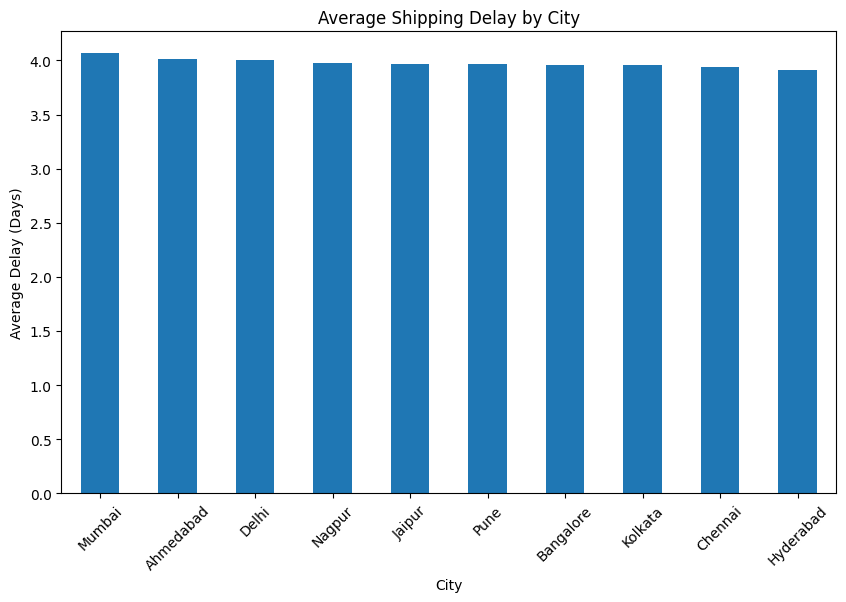

In [263]:
plt.figure(figsize=(10,6))

city_delay.plot(kind="bar")

plt.title("Average Shipping Delay by City")
plt.xlabel("City")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45)

plt.show()

Top 10 Slowest Orders

In [264]:
slow_orders = orders.sort_values(
    "shipping_delay",
    ascending=False
).head(10)

slow_orders

,order_id,product_id,customer_id,price,quantity,discount_percent,shipping_cost,payment_method,order_status,shipping_city,order_date,shipping_date,revenue,shipping_delay
2797,100002797,166172,62112,120.91,3,0,7.80,UPI,Shipped,Ahmedabad,2023-11-25,2023-12-02,362.73,7
9958,100009958,240891,31015,413.22,5,0,6.49,Net Banking,Delivered,Jaipur,2023-12-02,2023-12-09,2066.10,7
0,100000000,941235,43871,78.63,5,0,24.21,Net Banking,Delivered,Pune,2024-03-07,2024-03-14,393.15,7
6528,100006528,240891,67764,373.02,4,0,2.49,UPI,Delivered,Delhi,2023-11-17,2023-11-24,1492.08,7
31,100000031,619501,94579,528.29,2,10,19.62,Debit Card,Processing,Chennai,2023-03-15,2023-03-22,1056.58,7
2827,100002827,696853,15311,403.48,1,10,12.71,Net Banking,Cancelled,Delhi,2023-11-21,2023-11-28,403.48,7
2798,100002798,571325,87241,212.20,1,15,3.69,Debit Card,Returned,Nagpur,2024-07-01,2024-07-08,212.20,7
6537,100006537,900875,81221,523.88,3,0,11.12,UPI,Shipped,Mumbai,2023-03-14,2023-03-21,1571.64,7
2788,100002788,240891,88142,441.67,4,0,17.73,Net Banking,Cancelled,Jaipur,2023-05-02,2023-05-09,1766.68,7
6541,100006541,619501,20253,153.85,2,20,5.03,Net Banking,Shipped,Chennai,2023-04-04,2023-04-11,307.70,7


Shipping Delay Distribution

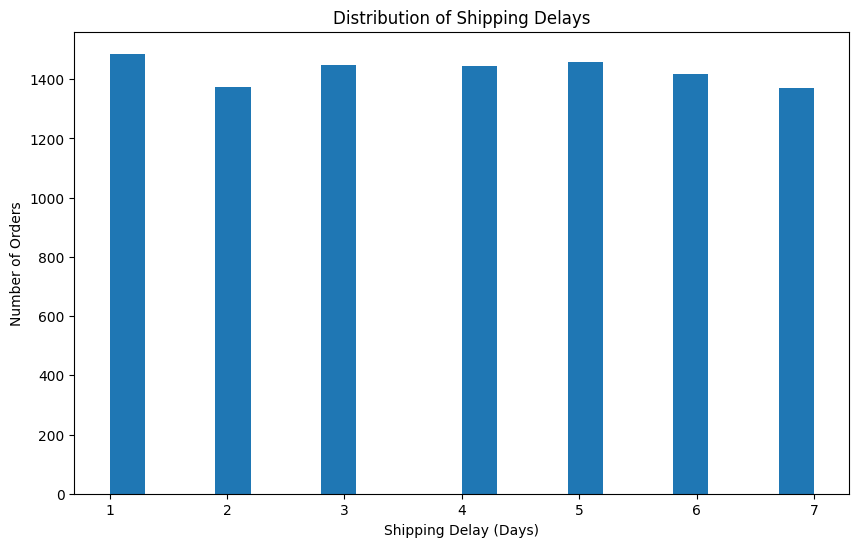

In [265]:
plt.figure(figsize=(10,6))

plt.hist(orders["shipping_delay"], bins=20)

plt.title("Distribution of Shipping Delays")
plt.xlabel("Shipping Delay (Days)")
plt.ylabel("Number of Orders")

plt.show()

Most deliveries occur between 1–4 days.

In [266]:
late_orders = orders[orders["shipping_delay"] > 5]

late_orders.shape

(2789, 14)

In [267]:
late_percentage = (
    len(late_orders) / len(orders)
) * 100

round(late_percentage,2)

27.89

27.89% of orders were delivered late.

In [268]:
orders["month"] = orders["order_date"].dt.to_period("M")

In [269]:
orders["month"] = orders["order_date"].dt.to_period("M")

monthly_delay = (
    orders.groupby("month")["shipping_delay"]
    .mean()
)

monthly_delay

month
2023-01    4.071594
2023-02    3.945409
2023-03    4.024331
2023-04    4.022843
2023-05    3.966507
2023-06    3.831707
2023-07    3.859524
2023-08    3.993274
2023-09    3.953883
2023-10    4.039216
2023-11    4.018373
2023-12    4.095694
2024-01    3.983452
2024-02    4.031461
2024-03    3.743719
2024-04    4.112782
2024-05    4.052632
2024-06    4.029817
2024-07    3.966063
2024-08    3.950704
2024-09    3.894349
2024-10    3.856492
2024-11    3.876263
2024-12    4.087940
Freq: M, Name: shipping_delay, dtype: float64

Shipping Delay Trend Over Time

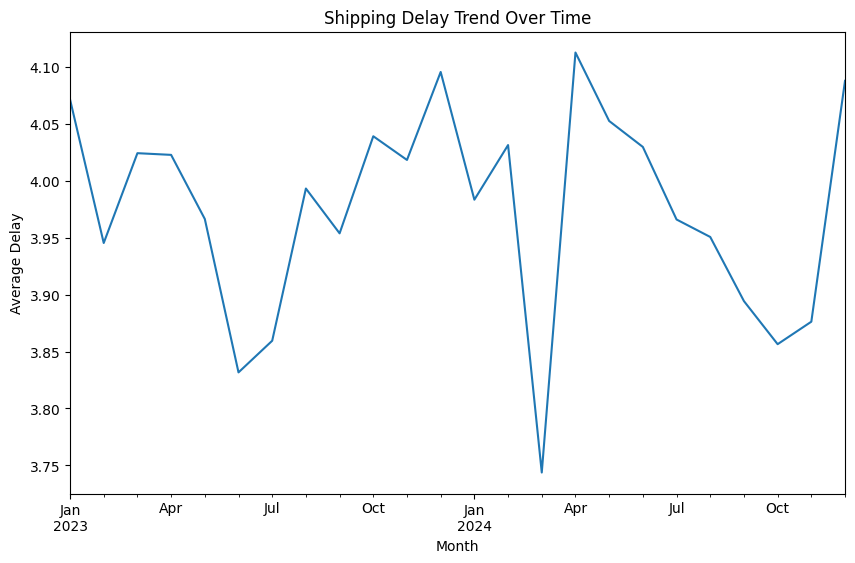

In [270]:
plt.figure(figsize=(10,6))

monthly_delay.plot()

plt.title("Shipping Delay Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Average Delay")

plt.show()

Logistics performance improved after March.

In [271]:
df = pd.merge(
    orders,
    products,
    on="product_id",
    how="left"
)
df

,order_id,product_id,customer_id,price,quantity,discount_percent,shipping_cost,payment_method,order_status,shipping_city,...,product_name,product_category,manufacturing_city,size,color,SKU,brand,material,base_price,launch_year
0,100000000,941235,43871,78.63,5,0,24.21,Net Banking,Delivered,Pune,...,Gaming Headset,Electronics,Bangalore,Standard,White,39364293,ZenWare,Steel,463.99,2022
1,100000001,988598,14630,435.52,2,5,18.21,Net Banking,Cancelled,Pune,...,Mechanical Keyboard,Electronics,Ahmedabad,L,Red,13897788,Vertex,Aluminum,384.21,2022
2,100000002,595185,77711,278.74,5,15,2.71,Wallet,Processing,Kolkata,...,Standing Desk Converter,Furniture,Mumbai,Compact,Gray,78786576,UrbanGear,Silicone,390.92,2020
3,100000003,900875,26473,581.22,1,0,3.63,Credit Card,Processing,Chennai,...,Fitness Smartwatch,Fitness,Pune,M,Silver,49780845,NovaTech,Wood,173.02,2024
4,100000004,897926,43077,91.28,5,20,2.87,Debit Card,Cancelled,Ahmedabad,...,4K Webcam,Electronics,Ahmedabad,M,White,77409318,UrbanGear,Plastic,387.56,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,100009995,166172,29944,160.96,1,10,22.70,Debit Card,Processing,Kolkata,...,Yoga Mat,Fitness,Ahmedabad,L,Blue,48139224,Vertex,Fabric,424.64,2023
9996,100009996,367459,24012,373.83,2,0,16.28,Net Banking,Shipped,Mumbai,...,Laptop Backpack,Accessories,Ahmedabad,XS,Red,42580007,Nimbus,Fabric,213.01,2020
9997,100009997,240891,20185,224.14,2,0,8.80,UPI,Cancelled,Jaipur,...,Running Shoes,Sports,Ahmedabad,Compact,Green,10282669,Nimbus,Fabric,140.50,2025
9998,100009998,783244,61214,64.17,2,0,11.72,Wallet,Processing,Bangalore,...,Graphic Tablet,Electronics,Ahmedabad,XS,Red,58954043,Vertex,Silicone,107.92,2023


Shipping Delay by Product Category

In [272]:
df = orders.merge(products, on="product_id")

In [273]:
category_delay = (
    df.groupby("product_category")["shipping_delay"]
    .mean()
    .sort_values(ascending=False)
)

category_delay

product_category
Sports         4.013740
Electronics    3.993599
Furniture      3.993187
Accessories    3.968276
Home           3.962617
Fitness        3.879554
Name: shipping_delay, dtype: float64

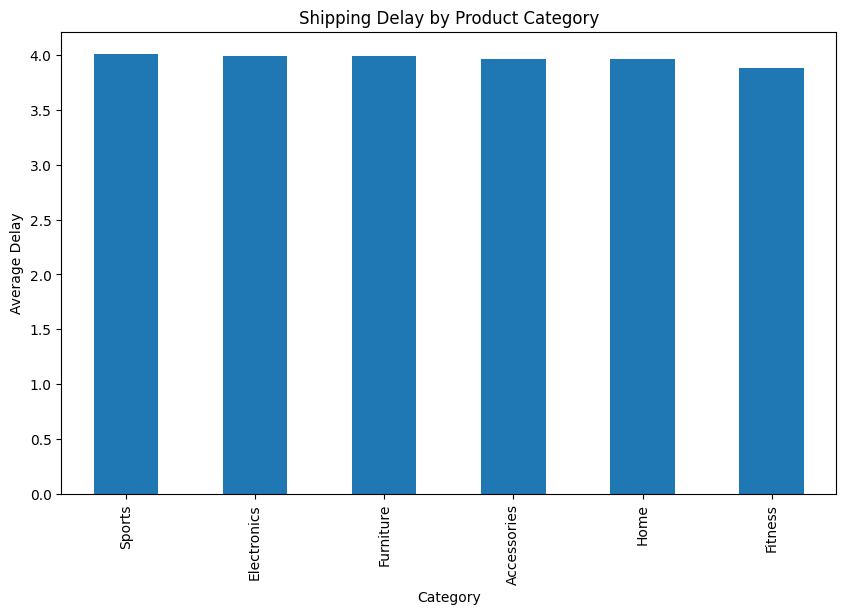

In [274]:
plt.figure(figsize=(10,6))

category_delay.plot(kind="bar")

plt.title("Shipping Delay by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Delay")

plt.show()

Exploratory Data Analysis (EDA)

In [275]:
# Total Revenue
df["revenue"].sum()

np.float64(9318892.370000001)

In [276]:
# Revenue by Category
category_sales = df.groupby("product_category")["revenue"].sum()

category_sales.sort_values(ascending=False)

product_category
Electronics    4962021.82
Fitness        1277105.73
Furniture      1238865.02
Accessories     666554.07
Sports          594191.26
Home            580154.47
Name: revenue, dtype: float64

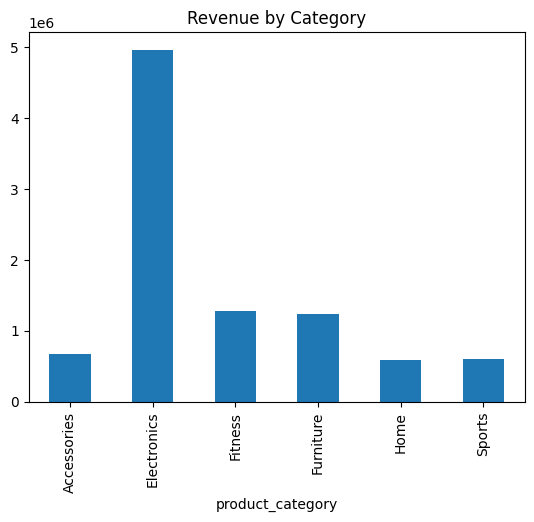

In [277]:
category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.show()

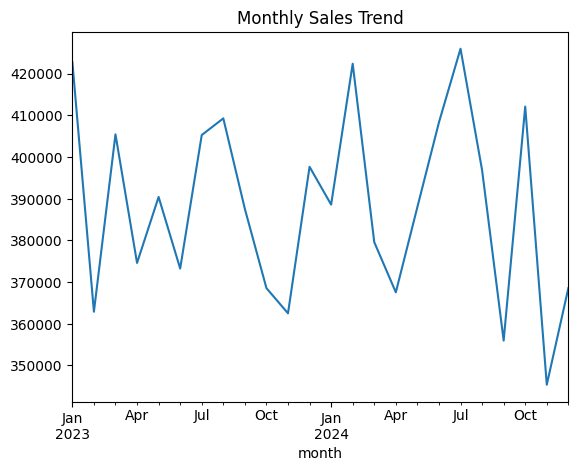

In [278]:
# Monthly Sales Trend
monthly_sales = df.groupby("month")["revenue"].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [279]:
# Top Products
top_products = df.groupby("product_name")["revenue"].sum()

top_products.sort_values(ascending=False).head(10)

product_name
Mechanical Keyboard         684222.33
Portable SSD                673305.38
Laptop Backpack             666554.07
Noise Cancelling Earbuds    650986.87
Fitness Smartwatch          646016.78
Standing Desk Converter     644949.84
Yoga Mat                    631088.95
Graphic Tablet              616234.82
Gaming Headset              615264.05
Running Shoes               594191.26
Name: revenue, dtype: float64

In [280]:
# Orders by City
df["shipping_city"].value_counts()

shipping_city
Kolkata      1035
Ahmedabad    1020
Chennai      1011
Jaipur       1009
Delhi        1006
Bangalore    1003
Pune          995
Hyderabad     991
Mumbai        979
Nagpur        951
Name: count, dtype: int64

In [281]:
# Customer Lifetime Value (CLV)

# CLV measures how valuable a customer is over time.

# Companies use this for:

# Marketing budgets

# Customer retention

# Loyalty programs

# Total Revenue per Customer

customer_revenue = df.groupby("customer_id")["revenue"].sum()

In [282]:
# Average Order Value
aov = df.groupby("customer_id")["revenue"].mean()

In [283]:
# Purchase Frequency
purchase_freq = df.groupby("customer_id")["order_id"].count()
purchase_freq

customer_id
10008    1
10031    1
10044    1
10064    1
10069    1
        ..
99939    1
99947    1
99960    1
99966    1
99996    1
Name: order_id, Length: 9477, dtype: int64

In [284]:
# Step 4: Estimate CLV

# Simple formula:

# CLV = Average Order Value × Purchase Frequency

clv = pd.DataFrame({
    "revenue": customer_revenue,
    "avg_order_value": aov,
    "purchase_frequency": purchase_freq
})

clv["CLV"] = clv["avg_order_value"] * clv["purchase_frequency"]
(clv)

,revenue,avg_order_value,purchase_frequency,CLV
customer_id,,,,
10008,186.46,186.46,1,186.46
10031,1022.70,1022.70,1,1022.70
10044,234.92,234.92,1,234.92
10064,1173.58,1173.58,1,1173.58
10069,1221.84,1221.84,1,1221.84
...,...,...,...,...
99939,539.00,539.00,1,539.00
99947,1598.55,1598.55,1,1598.55
99960,1367.90,1367.90,1,1367.90


In [285]:
 # Top Customers
clv.sort_values("CLV", ascending=False).head(10)

,revenue,avg_order_value,purchase_frequency,CLV
customer_id,,,,
48711,5602.65,2801.325000,2,5602.65
15371,5146.40,2573.200000,2,5146.40
67391,4873.22,2436.610000,2,4873.22
20055,4714.91,2357.455000,2,4714.91
55684,4677.20,2338.600000,2,4677.20
90018,4665.15,2332.575000,2,4665.15
65684,4665.10,2332.550000,2,4665.10
32838,4643.84,1547.946667,3,4643.84
53899,4619.44,1539.813333,3,4619.44


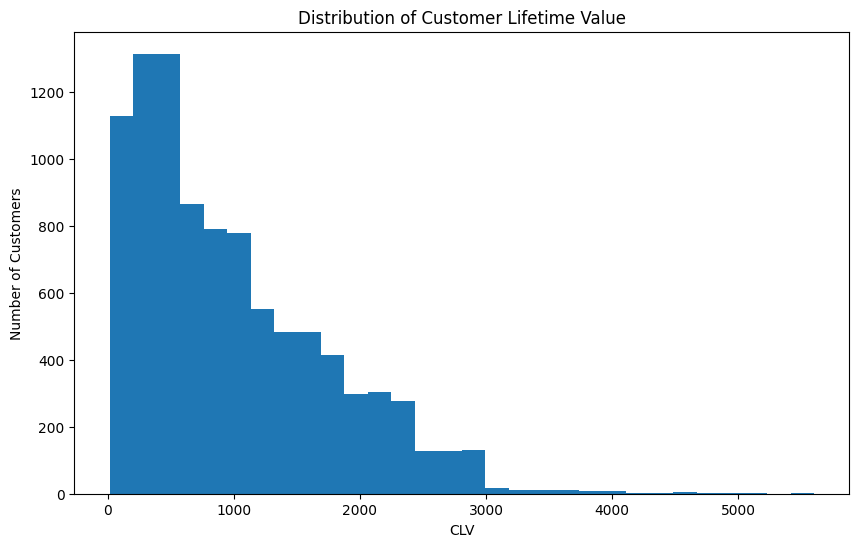

In [286]:
plt.figure(figsize=(10,6))
plt.hist(clv["CLV"], bins=30)
plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")
plt.show()

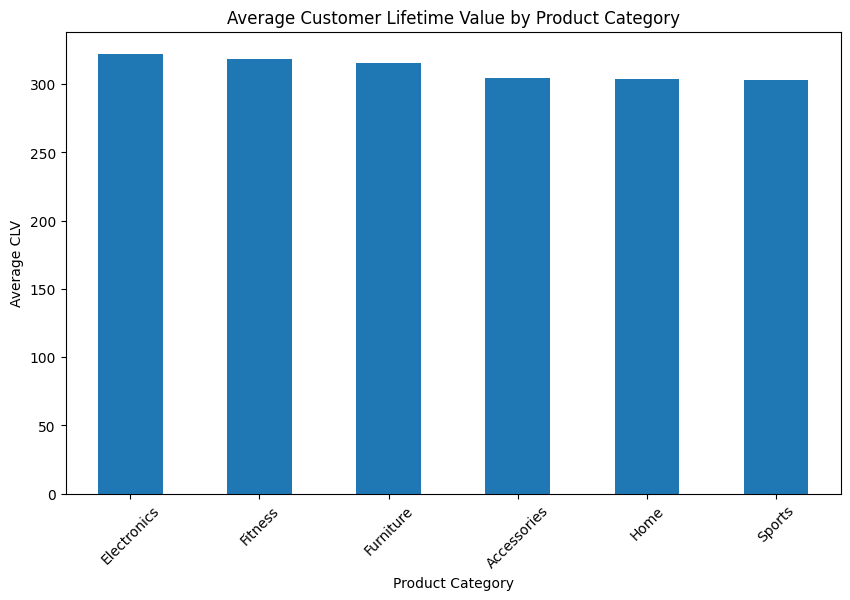

In [287]:
# Comparing Customer Lifetime Value (CLV) with Product Category helps answer an important business question:

# Which product categories attract the most valuable customers?

df = orders.merge(products, on="product_id")

clv_category = (
    df.groupby(["customer_id","product_category"])
    .agg({
        "price":"sum",
        "order_id":"count"
    })
    .reset_index()
)

clv_category.rename(columns={
    "price":"customer_revenue",
    "order_id":"purchase_frequency"
}, inplace=True)

clv_category["CLV"] = (
    clv_category["customer_revenue"]
)

category_clv = (
    clv_category.groupby("product_category")["CLV"]
    .mean()
    .sort_values(ascending=False)
)

category_clv

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

category_clv.plot(kind="bar")

plt.title("Average Customer Lifetime Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average CLV")

plt.xticks(rotation=45)

plt.show()


In [288]:
conn = sqlite3.connect("retailpulse.db")
cursor = conn.cursor()

In [289]:
orders = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\RetailPulse-Ecommerce-Analytics\data\orders_table.csv")
products = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\RetailPulse-Ecommerce-Analytics\data\products_table.csv")

In [290]:
orders.to_sql("orders", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)

20

In [291]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,orders
1,products


In [292]:
query = """
SELECT *
FROM orders
LIMIT 10;
"""

df = pd.read_sql(query, conn)

print(df)

    order_id  product_id  customer_id   price  quantity  discount_percent  \
0  100000000      941235        43871   78.63         5                 0   
1  100000001      988598        14630  435.52         2                 5   
2  100000002      595185        77711  278.74         5                15   
3  100000003      900875        26473  581.22         1                 0   
4  100000004      897926        43077   91.28         5                20   
5  100000005      498055        91652  312.69         4                 0   
6  100000006      223646        23687  563.70         4                 0   
7  100000007      240891        30573  132.50         3                20   
8  100000008      571325        22636  505.06         5                 0   
9  100000009      595185        15295   64.54         2                 0   

   shipping_cost payment_method order_status shipping_city  order_date  \
0          24.21    Net Banking    Delivered          Pune  2024-03-07   
1   

1️⃣ Total Revenue & Order KPIs

How is the overall business performing?

In [293]:
query = """
SELECT 
COUNT(order_id) AS total_orders,
COUNT(DISTINCT customer_id) AS total_customers,
SUM(price * quantity) AS total_revenue,
ROUND(SUM(price * quantity) / COUNT(order_id),2) AS avg_order_value
FROM orders;
"""
pd.read_sql(query, conn)

,total_orders,total_customers,total_revenue,avg_order_value
0,10000,9477,9318892.37,931.89


2️⃣ Revenue by Product Category

Which product categories generate the most revenue?

In [294]:
query = """
SELECT 
p.product_category,
SUM(o.price * o.quantity) AS revenue,
COUNT(o.order_id) AS total_orders
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.product_category
ORDER BY revenue DESC;
"""
pd.read_sql(query, conn)


,product_category,revenue,total_orders
0,Electronics,4962021.82,5312
1,Fitness,1277105.73,1345
2,Furniture,1238865.02,1321
3,Accessories,666554.07,725
4,Sports,594191.26,655
5,Home,580154.47,642


3️⃣ Top 10 Customers by Revenue

Who are the most valuable customers?

In [295]:
query="""

SELECT
customer_id,
COUNT(order_id) AS total_orders,
SUM(price * quantity) AS total_spent
FROM orders
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,customer_id,total_orders,total_spent
0,48711,2,5602.65
1,15371,2,5146.40
2,67391,2,4873.22
3,20055,2,4714.91
4,55684,2,4677.20
5,90018,2,4665.15
6,65684,2,4665.10
7,32838,3,4643.84
8,53899,3,4619.44
9,77509,2,4426.48


4️⃣ Monthly Revenue Trend (Time-Series Analysis)

How is revenue changing over time?

In [296]:
query="""
SELECT
strftime('%Y-%m', order_date) AS month,
SUM(price * quantity) AS revenue,
COUNT(order_id) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;
"""
pd.read_sql(query, conn)

,month,revenue,total_orders
0,2023-01,422776.52,433
1,2023-02,362869.86,403
2,2023-03,405420.45,411
3,2023-04,374564.61,394
4,2023-05,390396.64,418
5,2023-06,373221.50,410
6,2023-07,405247.60,420
7,2023-08,409250.76,446
8,2023-09,387530.64,412
9,2023-10,368524.49,408


5️⃣ Products With No Orders

Which products are not selling?

In [297]:
query="""
SELECT
p.product_id,
p.product_name,
p.product_category
FROM products p
LEFT JOIN orders o
ON p.product_id = o.product_id
WHERE o.product_id IS NULL;
"""
pd.read_sql(query, conn)

,product_id,product_name,product_category
0,320153,Smart Home Hub,Smart Home
1,198418,Electric Kettle,Home Appliances
2,611554,Air Fryer,Home Appliances
3,129724,Coffee Mug,Kitchen
4,976363,Water Bottle,Outdoor


In [298]:
# Customer Revenue
query="""
SELECT
customer_id,
SUM(price * quantity) AS revenue
FROM orders
GROUP BY customer_id
ORDER BY revenue DESC;
"""
pd.read_sql(query, conn)

,customer_id,revenue
0,48711,5602.65
1,15371,5146.40
2,67391,4873.22
3,20055,4714.91
4,55684,4677.20
...,...,...
9472,50217,16.88
9473,34722,16.58
9474,71665,16.12
9475,85013,15.61


Customer Lifetime Value (CLV)

CLV estimates how much revenue a customer generates over time.

In [299]:
query="""
SELECT
customer_id,
COUNT(order_id) AS purchase_frequency,
SUM(price * quantity) AS total_revenue,
AVG(price * quantity) AS avg_order_value
FROM orders
GROUP BY customer_id;
"""
pd.read_sql(query,conn)

,customer_id,purchase_frequency,total_revenue,avg_order_value
0,10008,1,186.46,186.46
1,10031,1,1022.70,1022.70
2,10044,1,234.92,234.92
3,10064,1,1173.58,1173.58
4,10069,1,1221.84,1221.84
...,...,...,...,...
9472,99939,1,539.00,539.00
9473,99947,1,1598.55,1598.55
9474,99960,1,1367.90,1367.90
9475,99966,1,198.18,198.18


In [300]:
clv = pd.read_sql(query, conn)

clv["CLV"] = (
    clv["purchase_frequency"] *
    clv["avg_order_value"]
)

In [301]:
clv.sort_values("CLV", ascending=False).head(10)

,customer_id,purchase_frequency,total_revenue,avg_order_value,CLV
4114,48711,2,5602.65,2801.325000,5602.65
592,15371,2,5146.40,2573.200000,5146.40
6104,67391,2,4873.22,2436.610000,4873.22
1125,20055,2,4714.91,2357.455000,4714.91
4847,55684,2,4677.20,2338.600000,4677.20
8453,90018,2,4665.15,2332.575000,4665.15
5938,65684,2,4665.10,2332.550000,4665.10
2485,32838,3,4643.84,1547.946667,4643.84
4667,53899,3,4619.44,1539.813333,4619.44
7167,77509,2,4426.48,2213.240000,4426.48


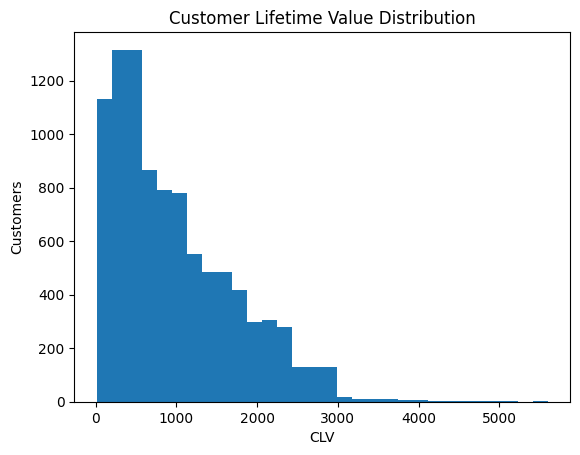

In [302]:
plt.hist(clv["CLV"], bins=30)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Customers")

plt.show()

Final Business Insights

conclusions you can include in your portfolio:

 1 Electronics products drive the majority of revenue.

 2 Five products have no orders and should be:

   discontinued

   re-priced

   marketed differently.

 3 Monthly sales trend is high in April to mid July .

 4  Kolkata , Ahemdabad and chennai  account for highest shipping orders .

 5 Shipping delays are highest in certain cities, requiring logistics optimization.
• Average delivery time: 3.98 days
• 27.89% of orders are delivered late 
• Electronics Sports , Furniture products have longer delivery times


CLV Distribution Insight
The CLV distribution is right-skewed, indicating that most customers generate relatively low revenue while a small group of high-value customers contributes a disproportionately large share of total revenue.
Customers buying Electronics generate the highest lifetime value.
Accessories customers generate lower revenue.


Overall Strategic Recommendations

Based on the analysis, the following strategies can improve business performance:

Focus marketing efforts on high-value customers identified through RFM and CLV analysis.

Develop customer loyalty programs to increase retention and repeat purchases.

Promote top-performing products and reevaluate underperforming inventory.

Improve logistics efficiency to reduce shipping delays and improve customer experience.

Use data-driven insights to design personalized marketing campaigns and product recommendations.